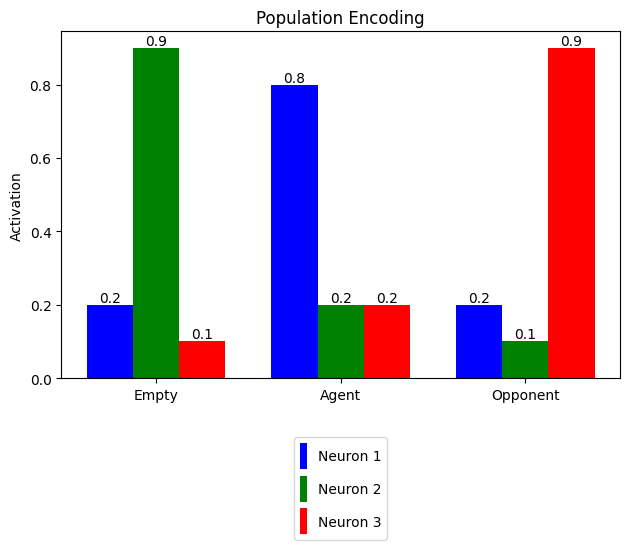

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the data for activations
neurons = ['Empty', 'Agent', 'Opponent']
empty_activations = [0.2, 0.8, 0.2]
opponent_activations = [0.9, 0.2, 0.1]
agent_activations = [0.1, 0.2, 0.9]

# Set up the bar positions
x = np.arange(len(neurons))
width = 0.25 # Width of each bar

# Create the figure and axis
fig, ax = plt.subplots()


# Plot the bars for each category with original colors
ax.bar(x - width, empty_activations, width, label='Neuron 1', color='blue')
ax.bar(x, opponent_activations, width, label='Neuron 2', color='green')
ax.bar(x + width, agent_activations, width, label='Neuron 3', color='red')

# Add text labels on the bars
for i in range(len(neurons)):
    ax.text(x[i] - width, empty_activations[i], str(empty_activations[i]), ha='center', va='bottom')
    ax.text(x[i], opponent_activations[i], str(opponent_activations[i]), ha='center', va='bottom')
    ax.text(x[i] + width, agent_activations[i], str(agent_activations[i]), ha='center', va='bottom')

# Add labels, title, and legend below the plot
ax.set_ylabel('Activation')
ax.set_title('Population Encoding')
ax.set_xticks(x)
ax.set_xticklabels(neurons)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, handleheight=2.5, handlelength=0.5)

# Adjust layout and display the plot
fig.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

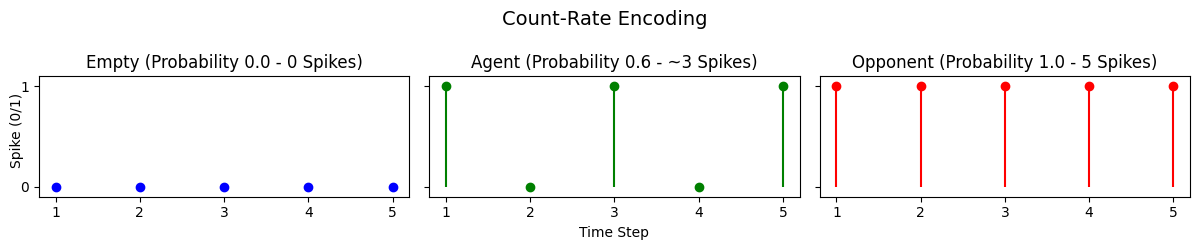

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Time steps
time_steps = np.array([1, 2, 3, 4, 5])

# Data for each subplot
# Left: Value 0, all 0 spikes, blue
spikes_left = np.zeros(5)
color_left = 'b'

# Middle: Value 1, ~3 spikes (sample: at 1,3,5), green
spikes_middle = np.array([1, 0, 1, 0, 1])
color_middle = 'g'

# Right: Value -1/2, all 5 spikes, red
spikes_right = np.ones(5)
color_right = 'r'

# Create figure with 3 subplots side by side
fig, axs = plt.subplots(1, 3, figsize=(12, 2.5), sharex=True, sharey=True)

# Function to plot stem
def plot_stem(ax, time, spikes, color, title):
    markerfmt = color + 'o'
    linefmt = color + '-'
    basefmt = ' '
    ax.stem(time, spikes, linefmt=linefmt, markerfmt=markerfmt, basefmt=basefmt)
    ax.set_title(title)
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['0', '1'])
    ax.grid(False)

# Left subplot
plot_stem(axs[0], time_steps, spikes_left, color_left, 'Empty (Probability 0.0 - 0 Spikes)')

# Middle subplot
plot_stem(axs[1], time_steps, spikes_middle, color_middle, 'Agent (Probability 0.6 - ~3 Spikes)')

# Right subplot
plot_stem(axs[2], time_steps, spikes_right, color_right, 'Opponent (Probability 1.0 - 5 Spikes)')

# Set xlabel on middle for centering
axs[1].set_xlabel('Time Step')

# Common ylabel on left
fig.text(0.004, 0.5, 'Spike (0/1)', va='center', rotation='vertical')

# Add this line after creating fig and axs
fig.suptitle('Count-Rate Encoding', fontsize=14)

plt.tight_layout()
plt.show()  # Or plt.savefig('side_by_side_plot.png') to save as file

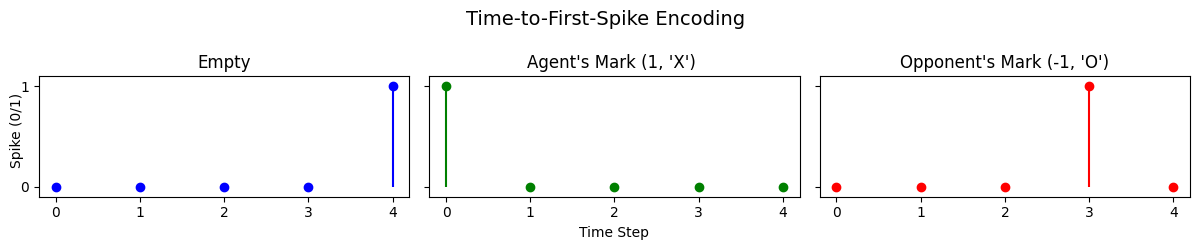

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Time steps for first graph (starting from 0)
time_steps = np.array([0, 1, 2, 3, 4])

# Data for each subplot in first graph
# Left: Agent's Mark, spike at 0, blue
spikes_left = np.array([1, 0, 0, 0, 0])
color_left = 'g'

# Middle: Opponent's Mark, spike at 2, red
spikes_middle = np.array([0, 0, 0, 1, 0])
color_middle = 'r'

# Right: Empty Position, spike at 4, black
spikes_right = np.array([0, 0, 0, 0, 1])
color_right = 'b'  # 'k' for black

# Create figure with 3 subplots side by side
fig, axs = plt.subplots(1, 3, figsize=(12, 2.5), sharex=True, sharey=True)

# Function to plot stem
def plot_stem(ax, time, spikes, color, title):
    markerfmt = color + 'o'
    linefmt = color + '-'
    basefmt = ' '
    ax.stem(time, spikes, linefmt=linefmt, markerfmt=markerfmt, basefmt=basefmt)
    ax.set_title(title)
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['0', '1'])
    ax.grid(False)

# Left subplot
plot_stem(axs[0], time_steps, spikes_right, color_right, 'Empty')


# Middle subplot
plot_stem(axs[1], time_steps, spikes_left, color_left, "Agent's Mark (1, 'X') ")


# Right subplot
plot_stem(axs[2], time_steps, spikes_middle, color_middle, "Opponent's Mark (-1, 'O')")


# Set xlabel on middle for centering
axs[1].set_xlabel('Time Step')

# Common ylabel on left
fig.text(0.004, 0.5, 'Spike (0/1)', va='center', rotation='vertical')

# Add suptitle
fig.suptitle('Time-to-First-Spike Encoding', fontsize=14)

plt.tight_layout()
plt.show()  # Or plt.savefig('ttfs_encoding_first.png') to save as file

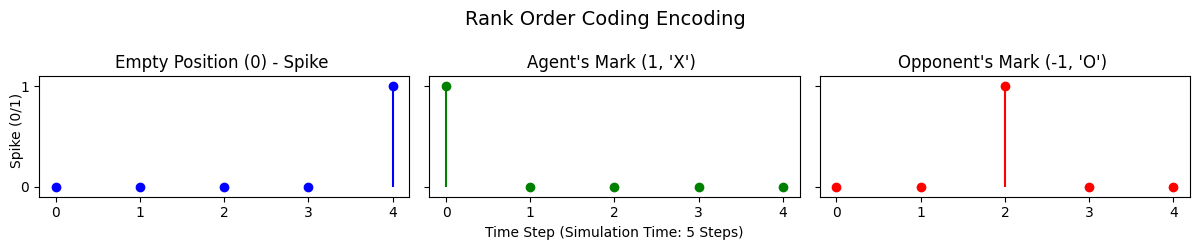

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Time steps (0 to 4 for 5 steps)
time_steps = np.array([0, 1, 2, 3, 4])

# Simulate base latencies with small Gaussian noise (sigma=0.05)
np.random.seed(42)  # For reproducibility

# Agent: base 0.0 + noise
latency_agent = 0.0 + np.random.normal(0, 0.05)
timestep_agent = int(np.clip(np.round(latency_agent), 0, 4))
spikes_agent = np.zeros(5)
spikes_agent[timestep_agent] = 1
color_agent = 'g'

# Opponent: base 2.0 + noise
latency_opponent = 2.0 + np.random.normal(0, 0.05)
timestep_opponent = int(np.clip(np.round(latency_opponent), 0, 4))
spikes_opponent = np.zeros(5)
spikes_opponent[timestep_opponent] = 1
color_opponent = 'r'

# Empty: base 4.0 + noise
latency_empty = 4.0 + np.random.normal(0, 0.05)
timestep_empty = int(np.clip(np.round(latency_empty), 0, 4))
spikes_empty = np.zeros(5)
spikes_empty[timestep_empty] = 1
color_empty = 'b'  # Black

# Create figure with 3 subplots side by side
fig, axs = plt.subplots(1, 3, figsize=(12, 2.5), sharex=True, sharey=True)

# Function to plot stem
def plot_stem(ax, time, spikes, color, title):
    markerfmt = color + 'o'
    linefmt = color + '-'
    basefmt = ' '
    ax.stem(time, spikes, linefmt=linefmt, markerfmt=markerfmt, basefmt=basefmt)
    ax.set_title(title)
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['0', '1'])
    ax.grid(False)

# Left subplot: Agent
plot_stem(axs[1], time_steps, spikes_agent, color_agent, f"Agent's Mark (1, 'X') ")

# Middle subplot: Opponent
plot_stem(axs[2], time_steps, spikes_opponent, color_opponent, f"Opponent's Mark (-1, 'O') ")

# Right subplot: Empty
plot_stem(axs[0], time_steps, spikes_empty, color_empty, f"Empty Position (0) - Spike ")

# Set xlabel on middle for centering
axs[1].set_xlabel('Time Step (Simulation Time: 5 Steps)')

# Common ylabel on left
fig.text(0.004, 0.5, 'Spike (0/1)', va='center', rotation='vertical')

# Add suptitle
fig.suptitle('Rank Order Coding Encoding', fontsize=14)

plt.tight_layout()
plt.show()

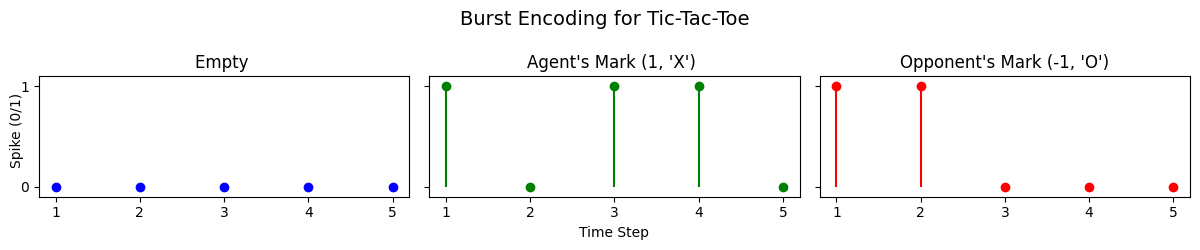

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Time steps for Tic-Tac-Toe (1 to 5)
time_steps_ttt = np.array([1, 2, 3, 4, 5])

# Burst patterns for Tic-Tac-Toe
burst_agent = np.array([1, 1, 1, 1, 0])
burst_opponent = np.array([1, 1, 0, 0, 0])
burst_empty = np.array([0, 0, 0, 0, 0])

# Apply 95% spike probability for Agent and Opponent (skip for Empty)
np.random.seed(42)  # For reproducibility
spikes_agent_ttt = (np.random.rand(5) < 0.95) * burst_agent
spikes_opponent_ttt = (np.random.rand(5) < 0.95) * burst_opponent
spikes_empty_ttt = burst_empty

# Colors
color_agent = 'g'
color_opponent = 'r'
color_empty = 'b'

# Create figure for Tic-Tac-Toe
fig_ttt, axs_ttt = plt.subplots(1, 3, figsize=(12, 2.5), sharex=True, sharey=True)

# Function to plot stem
def plot_stem(ax, time, spikes, color, title):
    markerfmt = color + 'o'
    linefmt = color + '-'
    basefmt = ' '
    ax.stem(time, spikes, linefmt=linefmt, markerfmt=markerfmt, basefmt=basefmt)
    ax.set_title(title)
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['0', '1'])
    ax.grid(False)

# Agent subplot
plot_stem(axs_ttt[1], time_steps_ttt, spikes_agent_ttt, color_agent, "Agent's Mark (1, 'X') ")

# Opponent subplot
plot_stem(axs_ttt[2], time_steps_ttt, spikes_opponent_ttt, color_opponent, "Opponent's Mark (-1, 'O')")

# Empty subplot
plot_stem(axs_ttt[0], time_steps_ttt, spikes_empty_ttt, color_empty, 'Empty ')

# Set xlabel on middle
axs_ttt[1].set_xlabel('Time Step')

# Common ylabel
fig_ttt.text(0.004, 0.5, 'Spike (0/1)', va='center', rotation='vertical')

# Suptitle
fig_ttt.suptitle('Burst Encoding for Tic-Tac-Toe', fontsize=14)

plt.tight_layout()
plt.show()  # Or plt.savefig('burst_ttt.png')

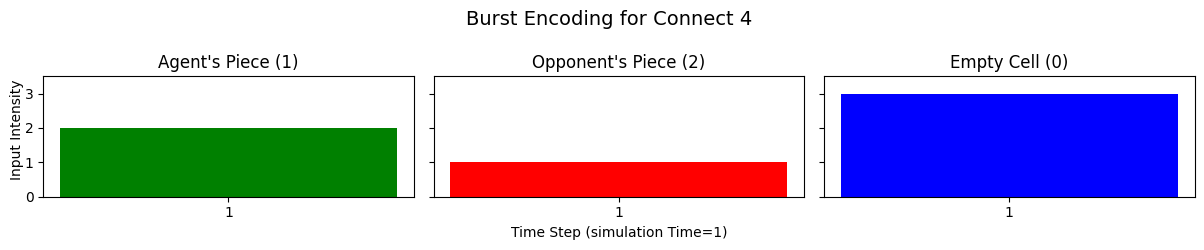

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# For Connect 4 (T=1, single time step)
time_steps_c4 = np.array([1])

# Intensity values for Connect 4
intensity_agent = 2.0
intensity_opponent = 1.0
intensity_empty = 3.0

# Add Gaussian noise (σ=0.01), clamped between 0 and 3.0
np.random.seed(42)
noise_agent = np.clip(intensity_agent + np.random.normal(0, 0.01), 0, 3.0)
noise_opponent = np.clip(intensity_opponent + np.random.normal(0, 0.01), 0, 3.0)
noise_empty = np.clip(intensity_empty + np.random.normal(0, 0.01), 0, 3.0)

# Colors
color_agent = 'g'
color_opponent = 'r'
color_empty = 'b'

# Create figure for Connect 4
fig_c4, axs_c4 = plt.subplots(1, 3, figsize=(12, 2.5), sharex=True, sharey=True)

# Function to plot bar for intensity
def plot_bar(ax, time, intensity, color, title):
    ax.bar(time, intensity, color=color, width=0.4)
    ax.set_title(title)
    ax.set_ylim(0, 3.5)  # Adjusted for intensity range
    ax.set_yticks([0, 1, 2, 3])
    ax.set_xticks([1])
    ax.set_xticklabels(['1'])
    ax.grid(False)

# Agent subplot
plot_bar(axs_c4[0], time_steps_c4, noise_agent, color_agent, f"Agent's Piece (1)")

# Opponent subplot
plot_bar(axs_c4[1], time_steps_c4, noise_opponent, color_opponent, f"Opponent's Piece (2)")

# Empty subplot
plot_bar(axs_c4[2], time_steps_c4, noise_empty, color_empty, f"Empty Cell (0)")

# Set xlabel on middle
axs_c4[1].set_xlabel('Time Step (simulation Time=1)')

# Common ylabel (changed to Intensity)
fig_c4.text(0.0004, 0.5, 'Input Intensity', va='center', rotation='vertical')

# Suptitle
fig_c4.suptitle('Burst Encoding for Connect 4', fontsize=14)

plt.tight_layout()
plt.show()  # Or plt.savefig('burst_c4.png')